In [33]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
%matplotlib inline
import pandas as pd

In [34]:

big5_df = pd.read_csv('drafts/datasets/big5-dataset.csv')
big5_df.drop_duplicates(inplace=True)
big5_df.dropna(inplace=True)
big5_df


,race,age,engnat,gender,hand,source,country,E1,E2,E3,...,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
0,3,53,1,1,1,1,US,4,2,5,...,4,1,3,1,5,1,4,2,5,5
1,13,46,1,2,1,1,US,2,2,3,...,3,3,3,3,2,3,3,1,3,2
2,1,14,2,2,1,1,PK,5,1,1,...,4,5,5,1,5,1,5,5,5,5
3,3,19,2,2,1,1,RO,2,5,2,...,4,3,5,2,4,2,5,2,5,5
4,11,25,2,2,1,2,US,3,1,3,...,3,1,1,1,3,1,3,1,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19714,11,15,1,2,1,2,SG,1,4,3,...,1,3,5,3,4,1,4,2,5,3
19715,3,37,1,2,1,2,US,2,3,2,...,1,2,3,2,3,3,4,2,3,3
19716,5,16,2,1,1,2,US,2,5,4,...,5,3,1,3,4,1,1,5,5,5
19717,12,16,1,1,1,5,NG,1,4,2,...,3,2,5,3,4,1,5,3,5,5


In [35]:

big5_df['A_total'] = big5_df.filter(regex='^A\\d').sum(axis=1)
big5_df['O_total'] = big5_df.filter(regex='^O\\d').sum(axis=1)
big5_df['C_total'] = big5_df.filter(regex='^C\\d').sum(axis=1)
big5_df['E_total'] = big5_df.filter(regex='^E\\d').sum(axis=1)
big5_df['N_total'] = big5_df.filter(regex='^N\\d').sum(axis=1)
big5_df

,race,age,engnat,gender,hand,source,country,E1,E2,E3,...,O6,O7,O8,O9,O10,A_total,O_total,C_total,E_total,N_total
0,3,53,1,1,1,1,US,4,2,5,...,1,4,2,5,5,32,31,31,32,19
1,13,46,1,2,1,1,US,2,2,3,...,3,3,1,3,2,31,26,28,28,29
2,1,14,2,2,1,1,PK,5,1,1,...,1,5,5,5,5,38,41,33,29,46
3,3,19,2,2,1,1,RO,2,5,2,...,2,5,2,5,5,37,37,34,36,43
4,11,25,2,2,1,2,US,3,1,3,...,1,3,1,5,3,40,22,26,26,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19714,11,15,1,2,1,2,SG,1,4,3,...,1,4,2,5,3,34,31,34,29,41
19715,3,37,1,2,1,2,US,2,3,2,...,3,4,2,3,3,28,26,30,29,25
19716,5,16,2,1,1,2,US,2,5,4,...,1,1,5,5,5,34,33,37,35,42
19717,12,16,1,1,1,5,NG,1,4,2,...,1,5,3,5,5,32,36,35,29,38


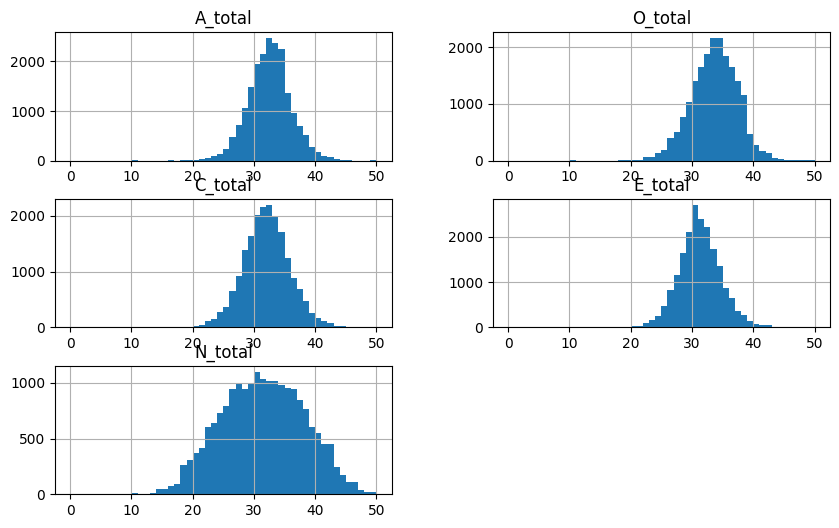

In [36]:
big5_df[['A_total', 'O_total', 'C_total', 'E_total', 'N_total']].hist(bins="auto", figsize=(10, 6))
plt.show()

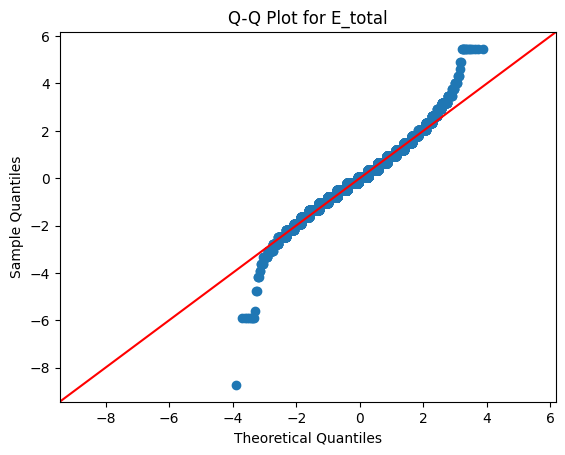

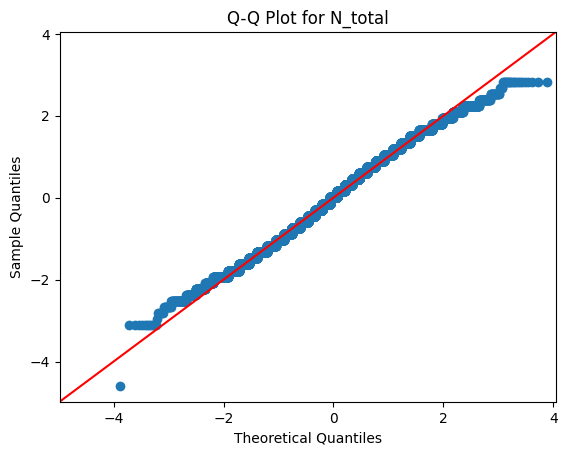

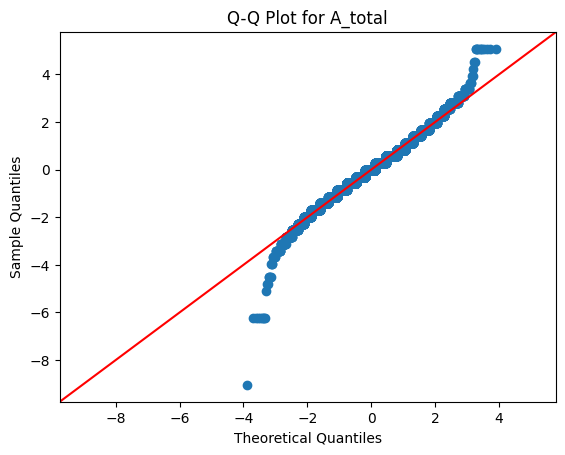

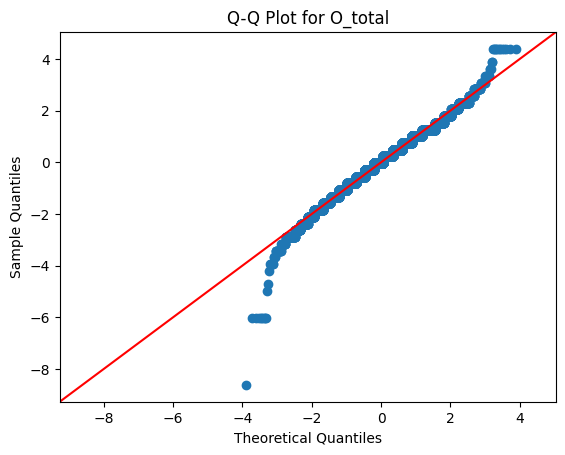

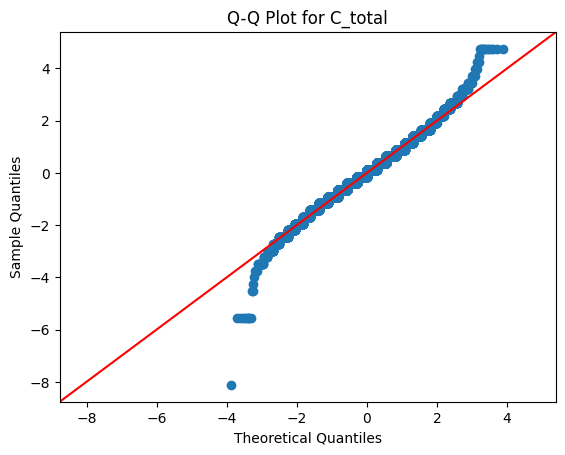

In [37]:
sm.qqplot(big5_df['E_total'], line='45', fit=True)
plt.title('Q-Q Plot for E_total')
plt.show()

sm.qqplot(big5_df['N_total'], line='45', fit=True)
plt.title('Q-Q Plot for N_total')
plt.show()

sm.qqplot(big5_df['A_total'], line='45', fit=True)
plt.title('Q-Q Plot for A_total')
plt.show()

sm.qqplot(big5_df['O_total'], line='45', fit=True)
plt.title('Q-Q Plot for O_total')
plt.show()

sm.qqplot(big5_df['C_total'], line='45', fit=True)
plt.title('Q-Q Plot for C_total')
plt.show()




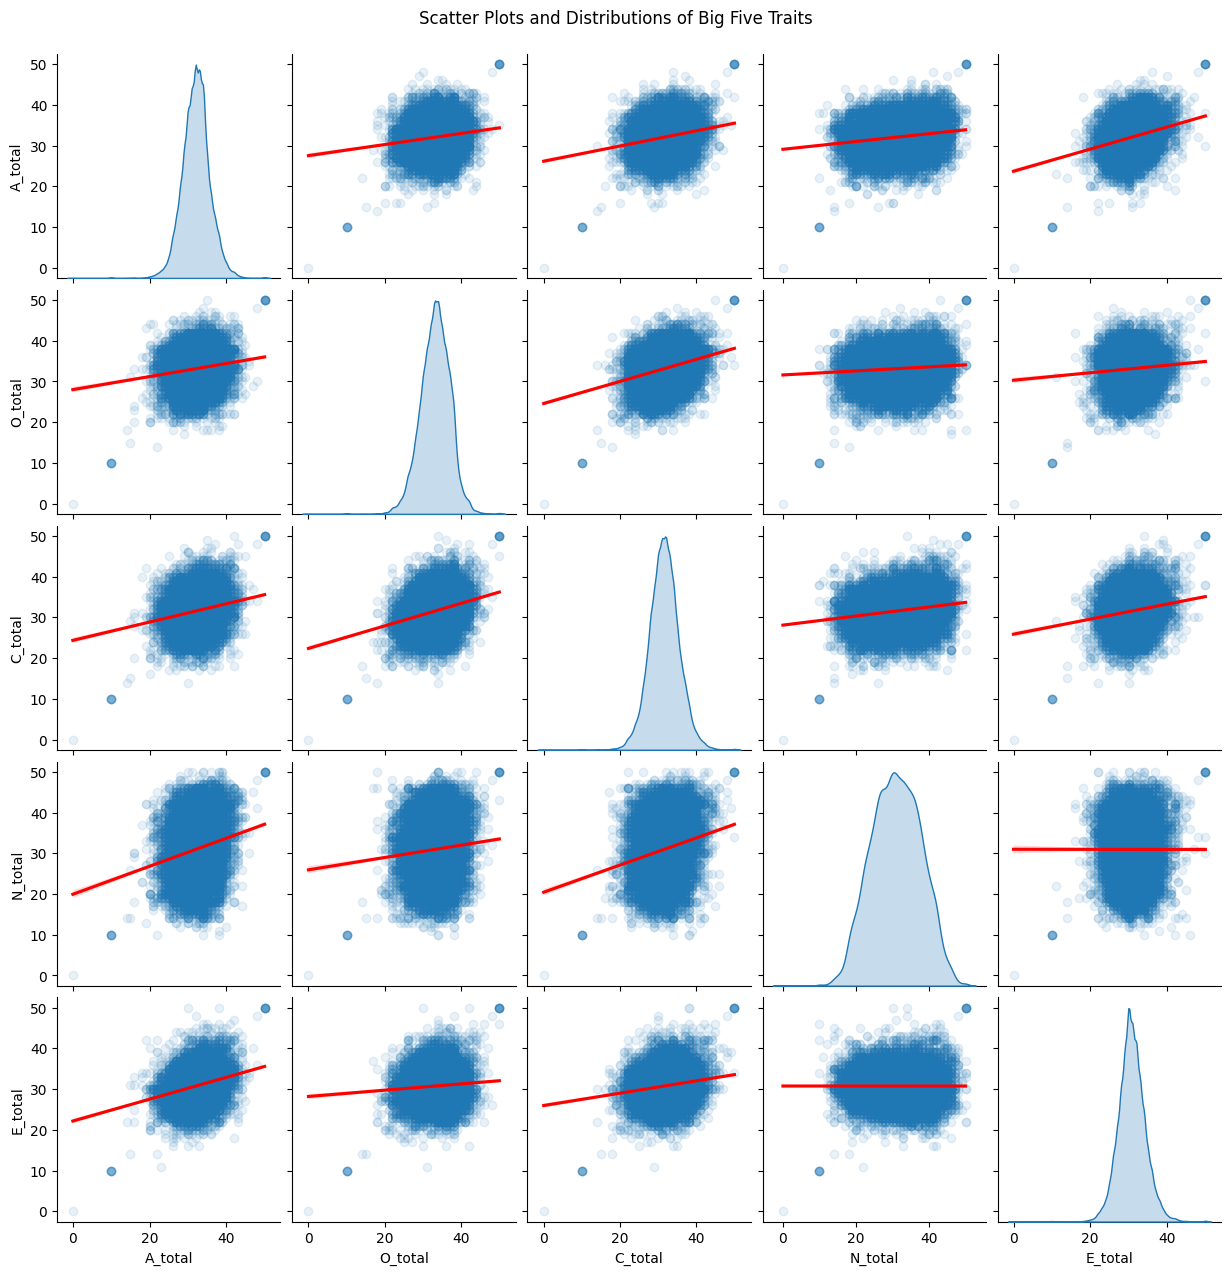

In [39]:
# Select the total columns
totals_df = big5_df[['A_total', 'O_total', 'C_total', 'N_total', 'E_total']]

# Create the pairplot
# 'kind="reg"' adds a regression line to the scatter plots
sns.pairplot(totals_df, kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})
plt.suptitle('Scatter Plots and Distributions of Big Five Traits', y=1.02)
plt.show()